[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/CyrilPitrou/primat/blob/master/notebooks/Sensitivity.ipynb)

# Sensitivity of BBN observables to physical parameters

## What this notebook computes

We compute the **logarithmic sensitivity** of each BBN observable $O$ to each
physical parameter $p$:
$$
S(O, p) \equiv \frac{\partial \ln O}{\partial \ln p}
\approx \frac{\ln O(p\,(1+\delta)) - \ln O(p\,(1-\delta))}{2\,\ln(1 + \delta)},
$$
evaluated by a symmetric finite difference with a 1% step ($\delta = 0.01$).

This dimensionless number tells you: **if parameter $p$ changes by 1%, by what
percentage does observable $O$ change?**

This is a one-call public API,
[`primat.sensitivity.sensitivity_table`](https://primat.readthedocs.io/en/latest/api/sensitivity.html)
(see the *How-to → Sensitivity tables* guide). This notebook is now a thin
demo of that API: it builds the list of parameters to vary, calls
`sensitivity_table` **once**, and plots the returned matrix. The heavy lifting
— running two bracketing BBN solves per parameter on the fast C backend and
sharing a single central solve — happens inside the API.

## Parameters varied

| Group | Parameters | Mechanism |
|-------|------------|-----------|
| Nuclear rates | All 12 key reaction rates | `delta_rxn` — fractional additive shift to the median rate |
| Weak sector | Neutron lifetime τ_n | `tau_n` parameter |
| Gravity | Newton constant G_N | `GN` parameter |
| Cosmology | Baryon density Ω_b h², ΔNeff | `Omegabh2`, `DeltaNeff` parameters |

## Observables

$Y_P$ (He-4 mass fraction), D/H, ³He/H, ⁷Li/H

In [1]:
import importlib.util, subprocess, sys

# In Colab (or any environment without a local primat checkout), pip-install
# the released package; local dev runs already have it importable (editable
# install / repo on sys.path via the cell below), so this is a no-op there.
if importlib.util.find_spec("primat") is None:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "primat"], check=True)

In [2]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from primat.config import PRIMATConfig
from primat.sensitivity import sensitivity_table, SensTarget
# Figures are written to plots/ next to this notebook; create it so the
# notebook also runs from a fresh clone or on Colab, where it does not exist.
os.makedirs('plots', exist_ok=True)


## 1. Choose the fiducial point and the parameters to vary

The fiducial is a standard small-network run at the Planck baryon density. We
then assemble the list of `targets` fed to `sensitivity_table`:

- **Nuclear rates** — passed as bare reaction names (e.g. `"n_p__d_g"`). The
  API auto-detects that these live in the reaction table and varies them
  through the `delta_<rxn>` mechanism, giving
  $\partial\ln O/\partial\ln(\text{rate})$.
- **Multiplicative parameters** — `tau_n`, `GN`, `Omegabh2` are scaled by
  $(1\pm\delta)$ about their fiducial values (Newton's constant enters through
  the Hubble rate $H\propto\sqrt{G_N}$).
- **Additive parameter** — `DeltaNeff` has fiducial value 0, so a proportional
  step is degenerate: there is no $\ln p$ to differentiate against. But it is
  only an *offset* on a parameter that has a perfectly good fiducial,
  $N_{\rm eff} = N_{\rm eff}^{\rm SM} + \Delta N_{\rm eff}$, so we vary it by
  $\pm 0.1$ species and pass `ref="Neff"`. The denominator becomes
  $\mathrm{d}\ln N_{\rm eff} = 2\,\text{step}/N_{\rm eff}$ and the row is
  $\partial\ln O/\partial\ln N_{\rm eff}$ — genuinely the same elasticity as
  every other row, which is what makes the heat-map comparable across rows.

In [3]:
# Fiducial run parameters -- all other knobs stay at their defaults.
FIDUCIAL = {
    'Omegabh2': 0.02242,
    'network':  'small',
}

OBSERVABLES = ['YPBBN', 'DoH', 'He3oH', 'Li7oH']
OBS_LABELS  = [r'$Y_P$', r'D/H', r'$^3$He/H', r'$^7$Li/H']

# The 12 key small-network reactions, with human-readable labels keyed *by
# reaction name* (so labels stay correct regardless of dict ordering).
RATE_NAMES = list(PRIMATConfig().p_rxn.keys())[:12]
RATE_LABEL_MAP = {
    'n_p__d_g':     r'p+n→d+γ',
    'd_p__He3_g':   r'd+p→³He+γ',
    'd_d__He3_n':   r'd+d→³He+n',
    'd_d__t_p':     r'd+d→t+p',
    't_p__a_g':     r't+p→⁴He+γ',
    't_d__a_n':     r't+d→⁴He+n',
    't_a__Li7_g':   r't+⁴He→⁷Li+γ',
    'He3_n__t_p':   r'³He+n→t+p',
    'He3_d__a_p':   r'³He+d→⁴He+p',
    'He3_a__Be7_g': r'³He+⁴He→⁷Be+γ',
    'Be7_n__Li7_p': r'⁷Be+n→⁷Li+p',
    'Li7_p__a_a':   r'⁷Li+p→⁴He+⁴He',
}
RATE_LABELS = [RATE_LABEL_MAP.get(n, n) for n in RATE_NAMES]

# Physical / cosmological parameters. tau_n, GN, Omegabh2 are multiplicative;
# DeltaNeff is additive about its zero fiducial, normalised by Neff so its
# row is the same d ln O / d ln p elasticity as the others.
PHYS_TARGETS = [
    SensTarget('tau_n',    label=r'$\tau_n$'),
    SensTarget('GN',       label=r'$G_N$'),
    SensTarget('Omegabh2', label=r'$\Omega_b h^2$'),
    # Additive knob, but reported as an elasticity like every other row:
    # ref='Neff' divides by d ln Neff = 2*step/Neff_central, so the cell is
    # dln(O)/dln(Neff). step=0.1 keeps it a derivative (step=1.0 is a +-33%
    # excursion in Neff, whose secant is ~1% off the tangent).
    SensTarget('DeltaNeff', label=r'$N_{\rm eff}$', kind='additive',
               step=0.1, ref='Neff'),
]

# Rate targets carry pretty labels too (bare strings would work identically
# for the numbers, but nicer axis labels help the heat-map).
RATE_TARGETS = [SensTarget(n, label=RATE_LABEL_MAP.get(n, n)) for n in RATE_NAMES]

## 2. Compute the whole sensitivity matrix in one call

`sensitivity_table` runs the fiducial solve once, then two bracketing solves
per target, and returns a `SensitivityTable` with `.values`, `.to_markdown()`,
and `.to_dataframe()` views.

In [4]:
tab = sensitivity_table(
    params=FIDUCIAL,
    observables=OBSERVABLES,
    targets=RATE_TARGETS + PHYS_TARGETS,
    rel_step=0.01,
    obs_labels=OBS_LABELS,
)

print('Fiducial observables:')
print(f"  YP    = {tab.fiducial['YPBBN']:.6f}")
print(f"  D/H   = {tab.fiducial['DoH']:.4e}")
print(f"  He3/H = {tab.fiducial['He3oH']:.4e}")
print(f"  Li7/H = {tab.fiducial['Li7oH']:.4e}")

# Split the matrix back into the rate block and the physical block for display.
n_rates    = len(RATE_TARGETS)
rate_sens  = tab.values[:n_rates]
phys_sens  = tab.values[n_rates:]
phys_names = [t.display_label() for t in PHYS_TARGETS]

Fiducial observables:
  YP    = 0.246999
  D/H   = 2.4359e-05
  He3/H = 1.0399e-05
  Li7/H = 5.5577e-10


## 3. Printed summary tables

Straight from the returned matrix. `SensitivityTable.to_markdown()` also emits
a paste-ready GitHub table (used at the bottom of this notebook).

In [5]:
col_w = 12
header = f"{'Parameter':<26}" + ''.join(f'{l:>{col_w}}' for l in OBS_LABELS)
sep    = '-' * (26 + col_w * len(OBSERVABLES))

print('\n' + '=' * len(sep))
print('SENSITIVITY TABLE  d ln(O) / d ln(p)')
print('(response of observable to a 1% fractional change in parameter)')
print('=' * len(sep))

print('\n--- Nuclear reaction rates (response per 1% change) ---')
print(header)
print(sep)
for i, label in enumerate(RATE_LABELS):
    row = f'{label:<26}' + ''.join(f'{rate_sens[i,j]:>{col_w}.7f}' for j in range(len(OBSERVABLES)))
    print(row)

print('\n--- Physical parameters (response per 1% change) ---')
print(header)
print(sep)
for i, label in enumerate(phys_names):
    row = f'{label:<26}' + ''.join(f'{phys_sens[i,j]:>{col_w}.7f}' for j in range(len(OBSERVABLES)))
    print(row)


SENSITIVITY TABLE  d ln(O) / d ln(p)
(response of observable to a 1% fractional change in parameter)

--- Nuclear reaction rates (response per 1% change) ---
Parameter                        $Y_P$         D/H    $^3$He/H    $^7$Li/H
--------------------------------------------------------------------------
t+d→⁴He+n                   -0.0000005  -0.0000401  -0.0075750  -0.0162075
⁷Li+p→⁴He+⁴He                0.0000001   0.0000524   0.0000366  -0.0460331
³He+n→t+p                    0.0000059   0.0252184  -0.1637739  -0.2678952
³He+⁴He→⁷Be+γ                0.0000000  -0.0000054  -0.0000104   0.9735287
t+⁴He→⁷Li+γ                 -0.0000004  -0.0000247  -0.0000059   0.0226260
d+d→³He+n                    0.0060445  -0.5450891   0.1982483   0.6734747
d+d→t+p                      0.0052282  -0.4580262  -0.2519895   0.0453467
d+p→³He+γ                    0.0002297  -0.3484240   0.3909872   0.6063934
t+p→⁴He+γ                    0.0000032  -0.0007055   0.0032649   0.0206620
³He+d→⁴He+p     

## 4. Heat-map visualisation

The colour encodes the sign and magnitude of the sensitivity: red = positive
(parameter up → observable up), blue = negative.

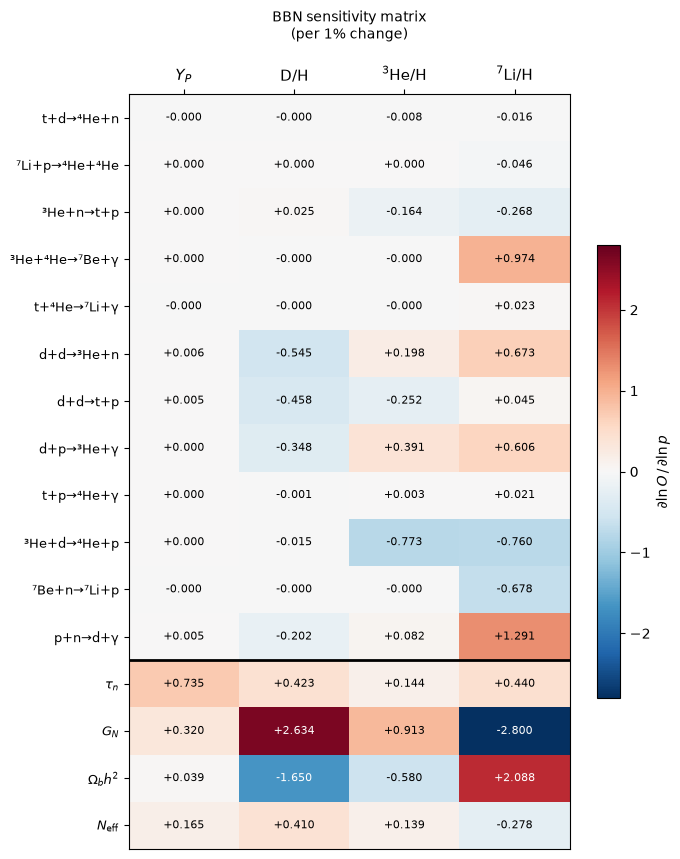

Saved plots/sensitivity_heatmap.pdf


In [6]:
all_labels = RATE_LABELS + phys_names
all_sens   = tab.values

fig, ax = plt.subplots(figsize=(7, 0.45 * len(all_labels) + 1.5))

vmax = np.max(np.abs(all_sens))
im = ax.imshow(all_sens, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')

# Annotate each cell with its value.
for i in range(len(all_labels)):
    for j in range(len(OBSERVABLES)):
        val = all_sens[i, j]
        color = 'white' if abs(val) > 0.5 * vmax else 'black'
        ax.text(j, i, f'{val:+.3f}', ha='center', va='center',
                fontsize=8, color=color)

# Separator line between rates and physical params.
ax.axhline(len(RATE_LABELS) - 0.5, color='black', lw=2)

ax.set_xticks(range(len(OBSERVABLES)))
ax.set_xticklabels(OBS_LABELS, fontsize=11)
ax.set_yticks(range(len(all_labels)))
ax.set_yticklabels(all_labels, fontsize=9)
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')

plt.colorbar(im, ax=ax, label=r'$\partial\ln O\,/\,\partial\ln p$', shrink=0.6)
ax.set_title('BBN sensitivity matrix\n(per 1% change)', fontsize=10, pad=40)

plt.tight_layout()
plt.savefig('plots/sensitivity_heatmap.pdf', bbox_inches='tight')
plt.show()
print('Saved plots/sensitivity_heatmap.pdf')

## 5. Markdown export

`to_markdown()` produces a table ready to paste into a paper draft, GitHub
issue, or the docs; `to_dataframe()` returns the same data as a pandas frame.

In [7]:
print(tab.to_markdown())

| Parameter | $Y_P$ | D/H | $^3$He/H | $^7$Li/H |
| --- | --- | --- | --- | --- |
| t+d→⁴He+n | -0.0000 | -0.0000 | -0.0076 | -0.0162 |
| ⁷Li+p→⁴He+⁴He | +0.0000 | +0.0001 | +0.0000 | -0.0460 |
| ³He+n→t+p | +0.0000 | +0.0252 | -0.1638 | -0.2679 |
| ³He+⁴He→⁷Be+γ | +0.0000 | -0.0000 | -0.0000 | +0.9735 |
| t+⁴He→⁷Li+γ | -0.0000 | -0.0000 | -0.0000 | +0.0226 |
| d+d→³He+n | +0.0060 | -0.5451 | +0.1982 | +0.6735 |
| d+d→t+p | +0.0052 | -0.4580 | -0.2520 | +0.0453 |
| d+p→³He+γ | +0.0002 | -0.3484 | +0.3910 | +0.6064 |
| t+p→⁴He+γ | +0.0000 | -0.0007 | +0.0033 | +0.0207 |
| ³He+d→⁴He+p | +0.0001 | -0.0147 | -0.7726 | -0.7601 |
| ⁷Be+n→⁷Li+p | -0.0000 | -0.0001 | -0.0000 | -0.6777 |
| p+n→d+γ | +0.0046 | -0.2024 | +0.0815 | +1.2914 |
| $\tau_n$ | +0.7354 | +0.4231 | +0.1439 | +0.4402 |
| $G_N$ | +0.3203 | +2.6339 | +0.9128 | -2.8003 |
| $\Omega_b h^2$ | +0.0392 | -1.6500 | -0.5799 | +2.0879 |
| $N_{\rm eff}$ | +0.1647 | +0.4105 | +0.1391 | -0.2783 |
